# Iris Flower Classification – Internship Project

This notebook is for my Code Alpha internship task.
I will use the Iris dataset to build a simple flower
classification model using basic machine learning steps.

**Project Made By : `Shivansh Mishra`**


## 1. Load Dataset in New Notebook

In this section I will:
- Import the basic Python libraries I need
- Load the Iris CSV file from the project folder
- Take a quick look at the data (shape, columns, first few rows)

In [1]:
# basic imports for data handling and plots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
import joblib

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# load the iris dataset from the CSV kept in this folder
df = pd.read_csv("Iris_dataset.csv")

# just see first 5 rows to confirm it loaded correctly
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# check basic info about the dataframe
print("Shape of data :", df.shape)
print("\nColumns :", df.columns.tolist())
df.describe()

Shape of data : (150, 6)

Columns : ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [4]:
# see data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
# quick null check just to be safe
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

## 2. Recreate New DataFrame With Numeric Columns 

- Doing one-hot encoding on the `Species` column using `get_dummies`

Here I explore the species column a bit more.

In [6]:
# unique species present in the dataset
df["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [7]:
# recreate the one-hot encoding idea from the old code
df_encoded = pd.get_dummies(df, columns=["Species"])

df_encoded.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_Iris-setosa,Species_Iris-versicolor,Species_Iris-virginica
0,1,5.1,3.5,1.4,0.2,True,False,False
1,2,4.9,3.0,1.4,0.2,True,False,False
2,3,4.7,3.2,1.3,0.2,True,False,False
3,4,4.6,3.1,1.5,0.2,True,False,False
4,5,5.0,3.6,1.4,0.2,True,False,False


In [8]:

# sometimes get_dummies creates bool columns, convert them to int just like before
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_Iris-setosa,Species_Iris-versicolor,Species_Iris-virginica
0,1,5.1,3.5,1.4,0.2,1,0,0
1,2,4.9,3.0,1.4,0.2,1,0,0
2,3,4.7,3.2,1.3,0.2,1,0,0
3,4,4.6,3.1,1.5,0.2,1,0,0
4,5,5.0,3.6,1.4,0.2,1,0,0


In [9]:
# count how many rows we have for each species
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

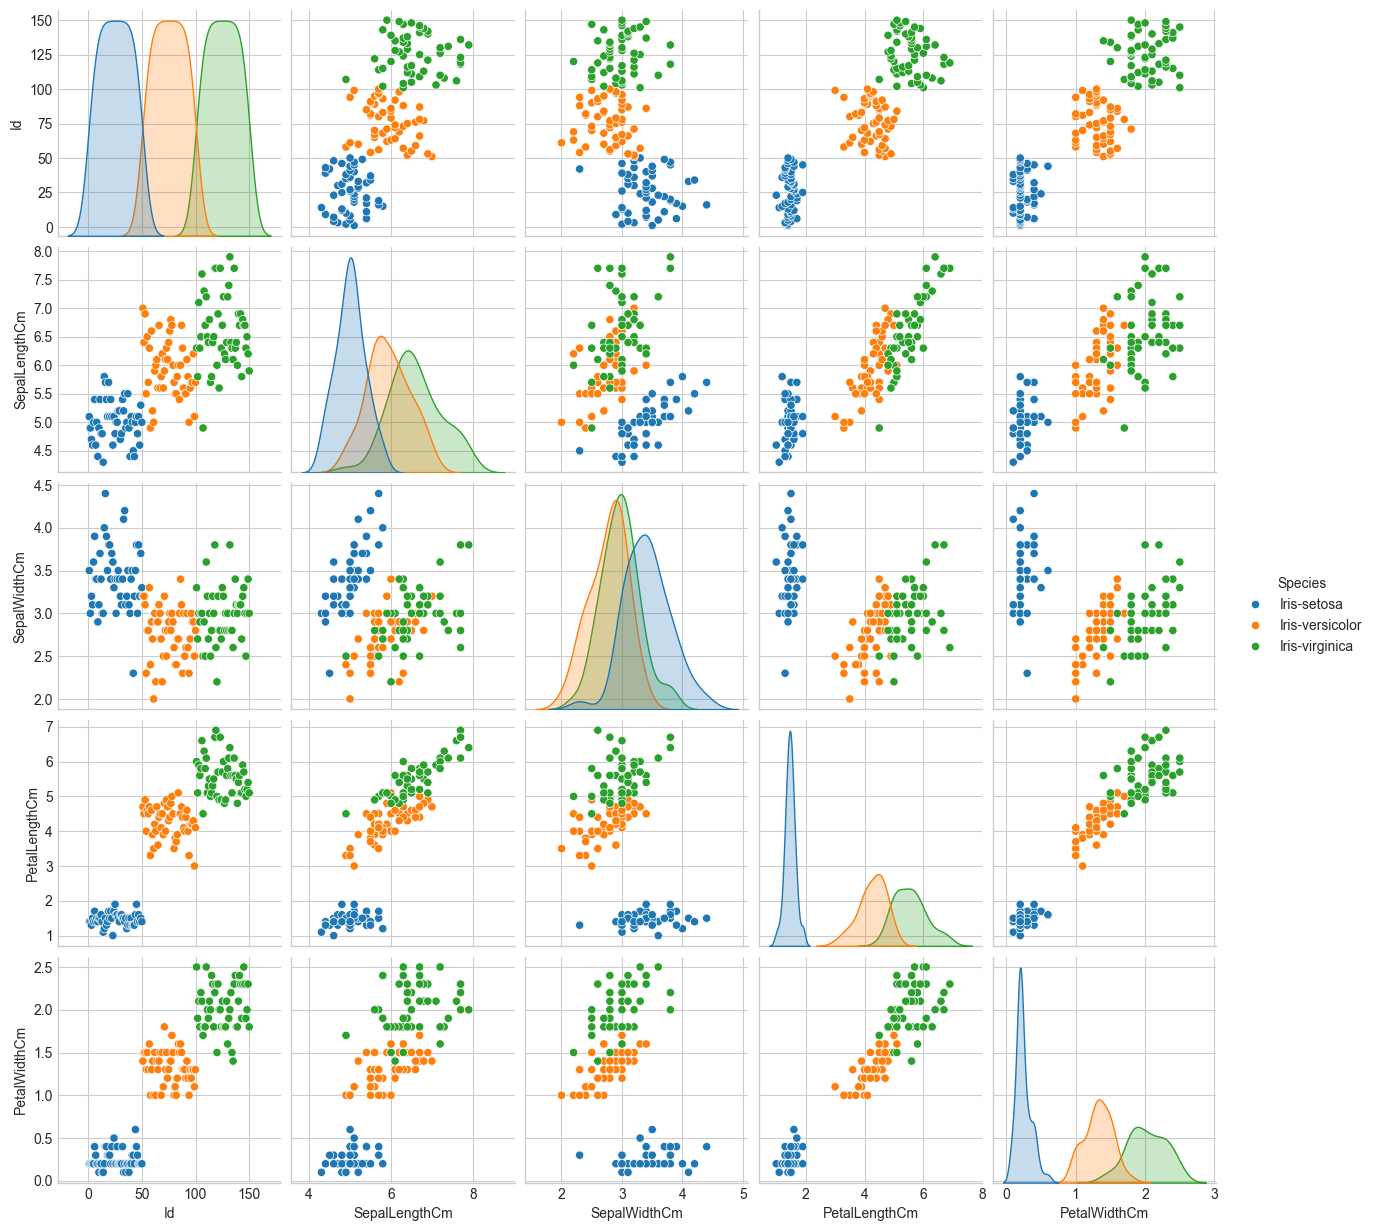

In [10]:
# simple pairplot to see how features are spread for each species
sns.pairplot(df, hue="Species")
plt.show()

## 3. Implement Required Project Tasks

Now I follow the project instructions:
- Use Iris flower measurements as input features
- Train a machine learning model (classification) using scikit-learn
- Split the data into train and test sets
- Check accuracy and other basic metrics


In [11]:
# select feature columns (inputs) and target column (output label)
feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
X = df[feature_cols]

# encode species names to numbers (0,1,2) using LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Species"])

X.head(), y[:5]

(   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
 0            5.1           3.5            1.4           0.2
 1            4.9           3.0            1.4           0.2
 2            4.7           3.2            1.3           0.2
 3            4.6           3.1            1.5           0.2
 4            5.0           3.6            1.4           0.2,
 array([0, 0, 0, 0, 0]))

In [12]:
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape :", X_train.shape)
print("Test shape  :", X_test.shape)

Train shape : (120, 4)
Test shape  : (30, 4)


In [13]:
# create a simple Logistic Regression model
log_reg_model = LogisticRegression(max_iter=200)

# train the model on training data
log_reg_model.fit(X_train, y_train)

"Model training is done"

'Model training is done'

## 4. Run, Test, and Analyze Results

Now I will:
- Use the trained model to predict on the test data
- Calculate accuracy score
- Show confusion matrix and classification report
- Write a short conclusion in normal student language

In [14]:
# make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Logistic Regression model: {accuracy:.3f}")

Accuracy of Logistic Regression model: 0.967


In [15]:
# confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



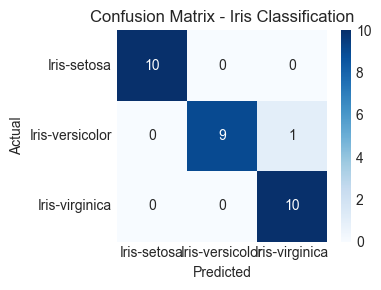

In [16]:
# visualize the confusion matrix as a heatmap
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Iris Classification")
plt.tight_layout()
plt.show()

### Small Conclusion (in simple words)

The Logistic Regression model is able to classify the three Iris species
with good accuracy. This small internship project is enough to
understand basic ideas of:
- how to load a dataset
- how to do small EDA
- how to train a simple ML model
- how to check accuracy and confusion matrix

For a bigger project we could try other models (like KNN, Decision Tree,
Random Forest) and compare them, but for now this is okay.

## 5. Export Results and Save Notebook

In this last part I will just show simple code to:
- Save the trained model to a file
- Save test predictions to a CSV file


In [17]:
# save the trained model (so it can be reused later)
joblib.dump(log_reg_model, "iris_log_reg_model.pkl")

# also save the test set with actual and predicted labels
test_results = X_test.copy()
test_results["true_species"] = label_encoder.inverse_transform(y_test)
test_results["predicted_species"] = label_encoder.inverse_transform(y_pred)
test_results.to_csv("iris_test_predictions.csv", index=False)

print("Model and prediction file saved successfully.")

Model and prediction file saved successfully.


That completes the Iris flower classification internship task.
All the steps from loading data to saving results are done
inside this single notebook.